In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/")
FILE_NAME = "df_final.csv"
path = DATA_DIR / FILE_NAME

In [4]:
df_final = pd.read_csv(path, low_memory=False)

In [5]:
df_final.head(32)

,ENTIDAD_FEDERATIVA,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024,Extorsion_2015_2019,Extorsion_2020_2025,Homicidio_Feminicidio_2015_2019,Homicidio_Feminicidio_2020_2025
0,Aguascalientes,38907.0,39738.0,37571.0,24874.0,23672,27687,54.4,53.9,497.0,624.0,1403.0,1575.0
1,Baja California,120507.0,126355.0,112513.0,114625.0,88940,97932,45.5,35.9,960.0,766.0,12607.0,18561.0
2,Baja California Sur,35149.0,38025.0,32368.0,28724.0,13705,14766,40.2,40.9,801.0,701.0,1880.0,978.0
3,Campeche,49237.0,48884.0,49614.0,28675.0,2454,17118,90.0,95.6,120.0,314.0,831.0,1293.0
4,Chiapas,192830.0,201770.0,183352.0,126496.0,20540,19040,153.5,142.9,965.0,403.0,7349.0,8427.0
5,Chihuahua,75407.0,77870.0,73086.0,76290.0,51784,64708,56.9,42.9,82.0,71.0,11331.0,15549.0
6,Distrito Federal,677682.0,646796.0,711155.0,639896.0,85594,92708,57.6,56.6,NaN,NaN,NaN,NaN
7,Coahuila de Zaragoza,75327.0,77977.0,72463.0,68685.0,33573,31574,47.3,43.8,153.0,271.0,2877.0,2653.0
8,Colima,39640.0,38988.0,40979.0,24394.0,10906,17167,64.0,47.2,226.0,758.0,3627.0,5315.0
9,Durango,67640.0,68135.0,66904.0,56620.0,27700,21388,83.3,67.1,378.0,366.0,2356.0,2255.0


---

# Modelo 1: K-fold cross validation con Random Forest Regressor

---

### Repitiendo la evaluación solo para el Fold 3

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# Definir características (X) y objetivo (y) con las nuevas variables
X = df_final[['Extorsion_2015_2019', 'Homicidio_Feminicidio_2015_2019', 'Pobreza_2015_2019']]
y = df_final['EMIGRANTES_2020']

# Eliminar filas con NaN si alguna de las nuevas columnas tiene valores faltantes
X = X.dropna()
y = y[X.index] # Asegurar que y tenga las mismas filas que X


# Re-inicializar KFold Cross-Validation para asegurar consistencia en las divisiones
kf_re_run = KFold(n_splits=5, shuffle=True, random_state=42)

# Encontrar los índices para el Fold 3 (índice 2 en un array 0-indexado)
fold_3_train_index = None
fold_3_test_index = None

print("Buscando los índices para el Fold 3...")
for i, (train_idx, test_idx) in enumerate(kf_re_run.split(X)):
    if i == 2: # Fold 3 corresponde al índice 2
        fold_3_train_index = train_idx
        fold_3_test_index = test_idx
        print(f"Índices encontrados para el Fold {i+1}.")
        break

if fold_3_train_index is not None and fold_3_test_index is not None:
    X_train_fold3, X_test_fold3 = X.iloc[fold_3_train_index], X.iloc[fold_3_test_index]
    y_train_fold3, y_test_fold3 = y.iloc[fold_3_train_index], y.iloc[fold_3_test_index]

    # Inicializar y entrenar el modelo RandomForestRegressor solo para el Fold 3
    model_rf_fold3 = RandomForestRegressor(random_state=42, n_estimators=100)
    model_rf_fold3.fit(X_train_fold3, y_train_fold3)

    # Realizar predicciones en el conjunto de prueba del Fold 3
    y_pred_rf_fold3 = model_rf_fold3.predict(X_test_fold3)

    # Calcular métricas para el Fold 3
    mse_fold3 = mean_squared_error(y_test_fold3, y_pred_rf_fold3)
    r2_fold3 = r2_score(y_test_fold3, y_pred_rf_fold3)

    print(f"\nMétricas para el Fold 3 (repetido):")
    print(f"  MSE: {mse_fold3:.2f}")
    print(f"  R-cuadrado: {r2_fold3:.2f}")
else:
    print("No se encontraron los índices para el Fold 3. Asegúrate de que el número de folds sea suficiente.")


Buscando los índices para el Fold 3...
Índices encontrados para el Fold 3.

Métricas para el Fold 3 (repetido):
  MSE: 710478061.65
  R-cuadrado: 0.85


### Visualizando la Importancia de las Características

Dado que el **Random Forest** es un modelo complejo compuesto por muchos árboles de decisión, no es posible visualizar una única ecuación explícita que lo represente. Sin embargo, podemos visualizar la importancia de las características (Feature Importance) para entender cuáles variables son las más relevantes para las predicciones del modelo. Esto nos dará una idea de cómo el modelo 'piensa'.

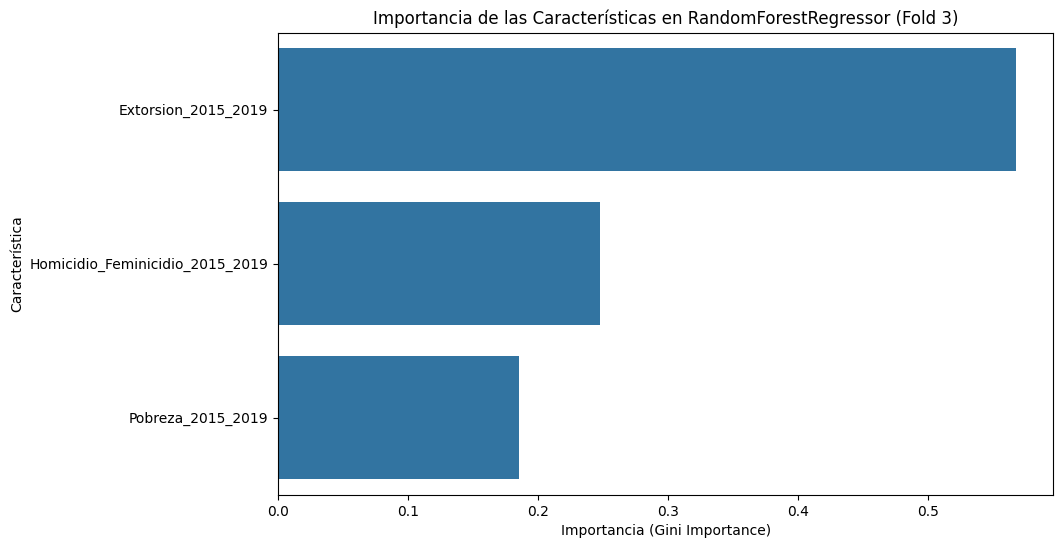

In [7]:
# El modelo ya está entrenado (model_rf_fold3 o model_rf_new, dependiendo del contexto)
# Usaremos model_rf_fold3 que es el último que se entrenó y evaluó explícitamente para el Fold 3

# Obtener la importancia de las características del modelo entrenado
feature_importances = model_rf_fold3.feature_importances_

# Crear un DataFrame para una mejor visualización
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Ordenar las características por importancia de forma descendente
features_df = features_df.sort_values(by='Importance', ascending=False)

# Graficar la importancia de las características
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Importancia de las Características en RandomForestRegressor (Fold 3)')
plt.xlabel('Importancia (Gini Importance)')
plt.ylabel('Característica')
plt.show()


+ Esto sugiere que la extorsión tuvo el mayor impacto en la predicción de la emigración, según este modelo en particular.

---

+ Ahora vamos a visualizar en una tabla los valores de la migración real al 2020 vs la migración pronosticada.

In [8]:
# Crear un DataFrame para comparar los valores reales y pronosticados del Fold 3
comparison_df_fold3 = pd.DataFrame({
    'EMIGRANTES_2020_Original': y_test_fold3,
    'EMIGRANTES_2020_Pronosticado': y_pred_rf_fold3
})

# Resetear el índice para que sea más fácil de leer, si es necesario
comparison_df_fold3 = comparison_df_fold3.reset_index(drop=True)

# Mostrar el DataFrame de comparación
display(comparison_df_fold3.head(7))


,EMIGRANTES_2020_Original,EMIGRANTES_2020_Pronosticado
0,120507.0,128465.99
1,35149.0,61892.05
2,233103.0,230246.05
3,212863.0,267754.94
4,93588.0,76841.99
5,125880.0,112366.45


### Visualización de Emigrantes Originales vs. Pronosticados

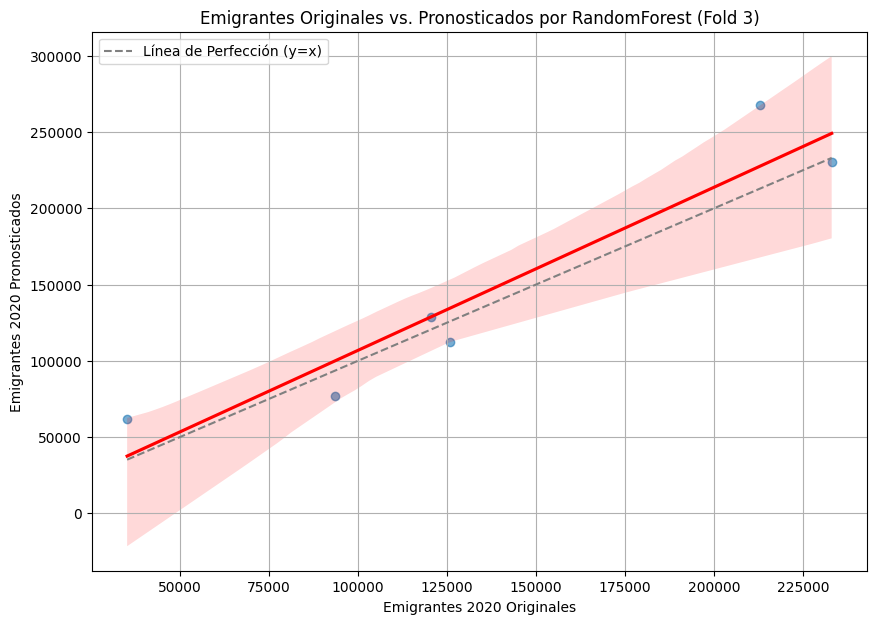

In [9]:
plt.figure(figsize=(10, 7))
sns.regplot(x='EMIGRANTES_2020_Original', y='EMIGRANTES_2020_Pronosticado', data=comparison_df_fold3, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.plot([comparison_df_fold3['EMIGRANTES_2020_Original'].min(), comparison_df_fold3['EMIGRANTES_2020_Original'].max()],
         [comparison_df_fold3['EMIGRANTES_2020_Original'].min(), comparison_df_fold3['EMIGRANTES_2020_Original'].max()],
         '--', color='gray', label='Línea de Perfección (y=x)')
plt.title('Emigrantes Originales vs. Pronosticados por RandomForest (Fold 3)')
plt.xlabel('Emigrantes 2020 Originales')
plt.ylabel('Emigrantes 2020 Pronosticados')
plt.legend()
plt.grid(True)
plt.show()


En este gráfico:

*   Cada punto representa un par de valor original y valor pronosticado.
*   La línea roja es la línea de regresión que muestra la tendencia de las predicciones.
*   La línea punteada gris representa la línea perfecta (donde `y = x`), es decir, donde los valores pronosticados serían exactamente iguales a los valores originales. Cuanto más cerca estén los puntos de esta línea, mejor es el rendimiento del modelo.
* La razón por la que solo se ven 6 puntos en el gráfico es directamente el resultado del proceso de validación cruzada K-Fold que aplicamos.
* El K-Fold divide los datos en varias partes (en este caso, 5 'folds' o 'pliegues'). Para cada 'fold', el modelo se entrena con la mayoría de los datos y se prueba con una porción más pequeña.
* En nuestro caso, el gráfico que se generó está mostrando los resultados solamente para el conjunto de prueba (test set) del Fold 3. Cuando dividimos los datos originales (X) en 5 folds, uno de esos folds, el número 3, terminó conteniendo solo 6 observaciones. Por lo tanto, el modelo hizo predicciones para esas 6 observaciones, y esas son las que se muestran en el gráfico de comparación de valores reales vs. pronosticados.

---

**Train = 26 estados $\sim$ 18.75%**

**Test = 6 estados $\sim$ 81.25**

---

**Nota:** es importante remarcar que en este caso el MSE y el R-cuadrado solo se obtiene usando este conjunto test, que para el Fold 3 resultaron ser solo 6 estados.

MSE = **710478061.65**

R-cuadrado = **0.85**

## Aplicar el modelo sobre todos los estados.

El modelo ya entrenado sí se puede aplicar sobre todos los estados (no solo sobre el test), vamos a haerlo y desplegar los resultados para comparar uno a uno.

In [10]:
y_pred_all_states = model_rf_fold3.predict(X)

comparison_df_all_states = pd.DataFrame({
    'EMIGRANTES_2020_Original': y,
    'EMIGRANTES_2020_Pronosticado': y_pred_all_states
})

comparison_df_all_states = comparison_df_all_states.reset_index(drop=True)

display(comparison_df_all_states.head(32))

,EMIGRANTES_2020_Original,EMIGRANTES_2020_Pronosticado
0,38907.0,54012.31
1,120507.0,128465.99
2,35149.0,61892.05
3,49237.0,48966.09
4,192830.0,193017.38
5,75407.0,97328.12
6,75327.0,69493.12
7,39640.0,53762.53
8,67640.0,68491.34
9,624146.0,507999.41


En la tabla anterior, puedes ver las predicciones del modelo `model_rf_new` para todos los estados en el DataFrame `df_final`. La columna 'EMIGRANTES_2020_Original' muestra los valores reales de emigración de 2020, y 'EMIGRANTES_2020_Pronosticado' son las predicciones hechas por el modelo.

Es importante recordar que el modelo `model_rf_new` fue entrenado con K-Fold Cross-Validation. Esto significa que cada estado se utilizó en el conjunto de entrenamiento en la mayoría de los folds y en el conjunto de prueba en uno de ellos. Por lo tanto, al predecir sobre todo el conjunto `X`, estamos evaluando el modelo en datos que ya ha "visto" en algún grado durante su entrenamiento. Las métricas de rendimiento en este conjunto completo (`X`) podrían ser más altas de lo que serían en un conjunto de datos completamente nuevo y no visto.

Podemos generar un diagrama de dispersión para visualizar esto:

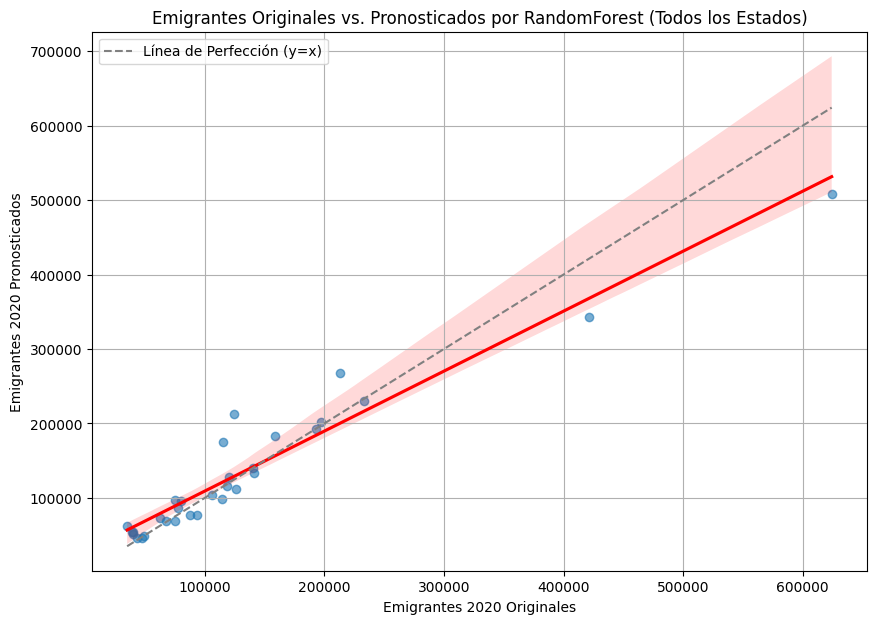

In [11]:
plt.figure(figsize=(10, 7))
sns.regplot(x='EMIGRANTES_2020_Original', y='EMIGRANTES_2020_Pronosticado', data=comparison_df_all_states, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.plot([comparison_df_all_states['EMIGRANTES_2020_Original'].min(), comparison_df_all_states['EMIGRANTES_2020_Original'].max()],
         [comparison_df_all_states['EMIGRANTES_2020_Original'].min(), comparison_df_all_states['EMIGRANTES_2020_Original'].max()],
         '--', color='gray', label='Línea de Perfección (y=x)')
plt.title('Emigrantes Originales vs. Pronosticados por RandomForest (Todos los Estados)')
plt.xlabel('Emigrantes 2020 Originales')
plt.ylabel('Emigrantes 2020 Pronosticados')
plt.legend()
plt.grid(True)
plt.show()

## Alcances y Limitaciones del Modelo

**Alcances del Modelo:**
*   **Identificación de Factores Clave:** El modelo ha identificado la extorsión como la característica más influyente, seguida por el homicidio/feminicidio y la pobreza, lo que proporciona información valiosa sobre los posibles impulsores de la emigración.
*   **Utilidad para Proyecciones:** Permite generar proyecciones de emigración para todos los estados, útil para estimaciones y planificación.

**Limitaciones del Modelo:**
*   **Tamaño del Conjunto de Datos:** El pequeño tamaño del dataset (32 estados) limita la capacidad del modelo para aprender patrones robustos y contribuye a la alta variabilidad.
*   **Variables Limitadas:** El modelo solo considera tres variables, mientras que la emigración es un fenómeno complejo influenciado por muchos otros factores no incluidos, lo que puede resultar en una imagen incompleta.
*   **'Caja Negra' del Random Forest:** Aunque la importancia de las características es útil, la naturaleza de 'caja negra' del Random Forest dificulta una interpretación detallada de cómo las variables interactúan para producir las predicciones, en comparación con modelos más transparentes.

---

# Modelo 2: k-means para agrupamiento

---

K-Means es un algoritmo de aprendizaje no supervisado. Su principal objetivo es encontrar estructuras o patrones ocultos en los datos sin la necesidad de etiquetas predefinidas.

En otras palabras, no se le da al algoritmo ejemplos de cómo deberían agruparse los datos, sino que él mismo descubre los grupos basándose en las similitudes entre las observaciones.

El objetivo sería que el algoritmo encuentre un agrupamiento (con mas de dos grupos) y que en alguno de ellos estén los estados con mas emigración, mas pobreza y mas delincuencia.

In [12]:
# Volví a cargar los datos, para tenerlos íntegro en un nuevo DF
df_clusters = pd.read_csv(path, low_memory=False)

### Preparación de Datos para el Segundo Modelo de Clustering

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Definir las características para el segundo clustering
features_for_clustering_2 = ['EMIGRANTES_2020', 'Total_Victimas_2015_2019', 'Pobreza_2015_2019']

# Crear un DataFrame con las características seleccionadas
df_clustering_2 = df_clusters[features_for_clustering_2].copy()

# Eliminar filas con NaN de las características seleccionadas para el clustering
df_clustering_2 = df_clustering_2.dropna()

# Guardar los índices de los estados que se mantienen después de eliminar NaNs
original_indices_2 = df_clustering_2.index

# Escalar los datos
scaler_2 = StandardScaler()
df_scaled_2 = scaler_2.fit_transform(df_clustering_2)
df_scaled_2 = pd.DataFrame(df_scaled_2, columns=features_for_clustering_2, index=original_indices_2)

display(df_scaled_2.head())

,EMIGRANTES_2020,Total_Victimas_2015_2019,Pobreza_2015_2019
0,-0.725358,-0.406395,-0.914348
1,-0.182922,0.643804,-1.214424
2,-0.750339,-0.566769,-1.393121
3,-0.656689,-0.747804,0.285958
4,0.297844,-0.456790,2.426952


### Determinando el número óptimo de clústeres (Método del Codo) para el Segundo Modelo

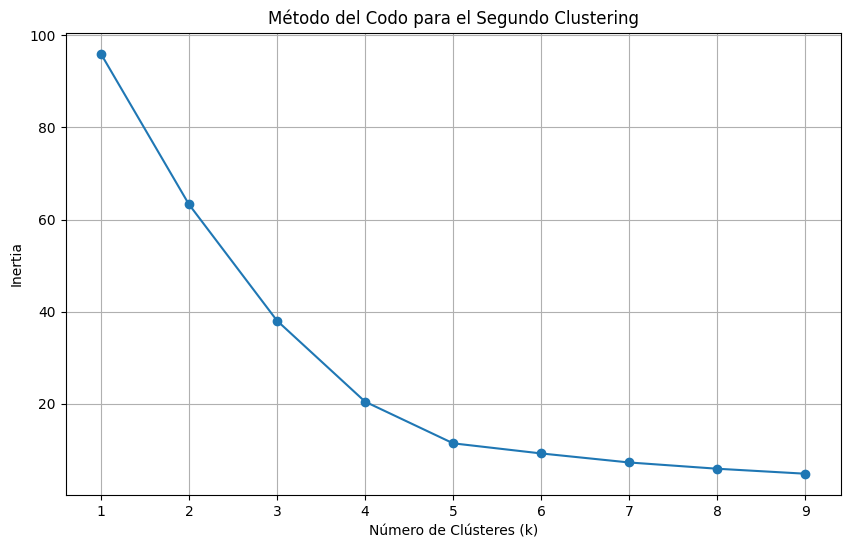

In [14]:
import matplotlib.pyplot as plt

inertia_2 = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled_2)
    inertia_2.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), inertia_2, marker='o')
plt.title('Método del Codo para el Segundo Clustering')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 10))
plt.grid(True)
plt.show()

En este caso la métrica es la inercia, donde se observe un menor cambio en esta cantidad se sugeriría como el número de cluster a usar.


El gráfico del método del codo sugiere que `k=3` o `k=4` podrían ser buenos valores. Para este ejemplo, procederemos con `k=4`.

In [15]:
# Aplicar K-Means con k=4
k = 4
kmeans_2 = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels_2 = kmeans_2.fit_predict(df_scaled_2)

# Añadir las etiquetas de clúster a los datos originales (filtrados por NaN)
# Asegúrate de que las etiquetas se alineen correctamente con los índices de df_clustering_2
df_clustering_2_labeled = df_clustering_2.copy()
df_clustering_2_labeled['Cluster'] = cluster_labels_2

# Añadir las etiquetas de clúster al DataFrame original df_clusters, manejando NaN
df_clusters_copy = df_clusters.copy()
df_clusters_copy['Cluster_2'] = pd.Series(dtype='int') # Initialize column with a proper dtype
df_clusters_copy.loc[original_indices_2, 'Cluster_2'] = cluster_labels_2

# Mostrar la distribución de los estados por clúster
print("Distribución de estados por clúster (Segundo Modelo):")
print(df_clusters_copy['Cluster_2'].value_counts().sort_index())

Distribución de estados por clúster (Segundo Modelo):
Cluster_2
0.0    19
1.0    10
2.0     2
3.0     1
Name: count, dtype: int64


### Coordenadas de los Centroides (k=4) en Escala Original

In [16]:
# Calcular los centroides en la escala original
centroids_scaled_2 = kmeans_2.cluster_centers_
centroids_original_2 = scaler_2.inverse_transform(centroids_scaled_2)

# Crear un DataFrame para los centroides en escala original
centroids_df_original_2 = pd.DataFrame(
    centroids_original_2,
    columns=features_for_clustering_2,
    index=[f'Cluster {i}' for i in range(k)]
)

# Mostrar las coordenadas de los centroides en la escala original
display(centroids_df_original_2)

,EMIGRANTES_2020,Total_Victimas_2015_2019,Pobreza_2015_2019
Cluster 0,87826.578947,33262.473684,63.121053
Cluster 1,168639.500000,39051.200000,116.080000
Cluster 2,650914.000000,88530.000000,74.100000
Cluster 3,79856.000000,366160.000000,100.300000


---

## Resumen de los Resultados de Clustering con k=4

**Distribución de Estados por Clúster:**
*   **Clúster 0 (19 estados):** Agrupa a la mayoría de los estados con valores moderados a bajos en emigración, víctimas y pobreza. Los centroides muestran promedios de `87,826` emigrantes, `33,262` víctimas y `63.12%` de pobreza. Este clúster representa un grupo de estados con niveles de problemáticas más contenidos en comparación con otros.
    *   *Estados principales:* Aguascalientes, Baja California, Baja California Sur, Campeche, Chihuahua, Coahuila de Zaragoza, Colima, Durango, Guanajuato, Jalisco, Nayarit, Nuevo León, Querétaro, Quintana Roo, San Luis Potosí, Sinaloa, Sonora, Tamaulipas, Yucatán.

*   **Clúster 1 (10 estados):** Este clúster se caracteriza por tener valores intermedios-altos de emigración y pobreza, pero con niveles de víctimas similares a los del Clúster 0. Sus centroides reflejan `168,639` emigrantes, `39,051` víctimas y `116.08%` de pobreza. Representa estados con desafíos significativos en términos de emigración y pobreza.
    *   *Estados principales:* Chiapas, Guerrero, Hidalgo, Michoacán de Ocampo, Oaxaca, Puebla, Tabasco, Tlaxcala, Veracruz de Ignacio de la Llave, Zacatecas.

*   **Clúster 2 (2 estados):** Incluye a 'Distrito Federal' y 'México', que son los estados con la **mayor cantidad de emigrantes** (`650,914` en promedio). También presentan un número elevado de víctimas (`88,530`) y una pobreza moderada (`74.10%`). Estos dos estados conforman un grupo distinto debido a su escala demográfica y de emigración.
    *   *Estados principales:* Distrito Federal, México.

*   **Clúster 3 (1 estado):** 'Morelos' se mantiene como un clúster individual, destacando por un número excepcionalmente alto de víctimas (`366,160`), a pesar de tener una emigración (`79,856`) y pobreza (`100.30%`) en rangos comparables a otros clústeres. Este clúster resalta a Morelos como un caso atípico o un `outlier` debido a su situación particular de violencia.
    *   *Estados principales:* Morelos.

**Análisis:**

La elección de `k=4` ha permitido una diferenciación más precisa, particularmente al aislar a Morelos como un clúster de alta violencia y al agrupar a los dos estados con mayor emigración (Distrito Federal y México) en un clúster separado. Esto sugiere que las dinámicas de emigración, violencia y pobreza varían significativamente entre los estados y que un modelo de cuatro clústeres captura mejor estas heterogeneidades. La visualización de estos clústeres confirmaría la separación observada en los centroides, mostrando cómo cada grupo ocupa un espacio distinto en el contexto de las variables analizadas.

## Ventajas del Clustering K-Means

Aplicar K-Means al DataFrame `df_clusters` utilizando las columnas 'EMIGRANTES_2020', 'Total_Victimas_2015_2019' y 'Pobreza_2015_2019' ofrece varias ventajas importantes para entender la dinámica de los estados mexicanos en relación con la emigración, la violencia y la pobreza:


1.  **Identificación de Perfiles de Riesgo/Necesidad:** Al crear estos grupos, podemos identificar perfiles de estados. Por ejemplo, podríamos encontrar un clúster de estados con alta emigración y alta pobreza, pero con un número moderado de víctimas; o un clúster donde la emigración no es tan alta, pero la cifra de víctimas es excepcionalmente elevada (como vimos con Morelos). Esta identificación de perfiles es fundamental para entender las dinámicas subyacentes.

2.  **Simplificación para la Toma de Decisiones:** En lugar de analizar 32 estados individualmente, el clustering reduce la complejidad a unos pocos grupos representativos (en nuestro caso, 4 clústeres). Para cada clúster, podemos analizar sus características promedio (los centroides) y entender rápidamente qué tipo de situación enfrentan los estados dentro de ese grupo. Esto facilita a los responsables de políticas públicas el diseño de estrategias más enfocadas y eficientes para cada tipo de estado.

3.  **Detección de Anomalías o Casos Únicos:** Como se observó con 'Morelos' en el Clúster 3 y con 'Distrito Federal' y 'México' en el Clúster 2, el K-Means es muy efectivo para señalar estados que son atípicos en una o más de las variables seleccionadas. Estos casos atípicos son importantes porque a menudo revelan fenómenos particulares que requieren una investigación más profunda o una atención especializada.

4.  **Comprensión de Interrelaciones entre Variables:** Aunque el K-Means agrupa por similitud general, al observar las características promedio de cada clúster, podemos inferir cómo 'EMIGRANTES_2020', 'Total_Victimas_2015_2019' y 'Pobreza_2015_2019' se combinan e interactúan para definir cada grupo de estados. Por ejemplo, si un clúster tiene alta emigración y alta pobreza, pero bajas víctimas, sugiere una dinámica diferente a un clúster con alta emigración y muchas víctimas.

En resumen, K-Means es una herramienta poderosa en este contexto para transformar datos brutos de estados en información estructurada y perfiles claros, lo que mejora significativamente nuestra capacidad de comprensión y, potencialmente, la formulación de respuestas dirigidas a los desafíos de emigración, violencia y pobreza en México.

---

# Modelo 3: Classification And Regression Tree

---


In [17]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/")
FILE_NAME = "Estatal_Victimas_2015_2025_ene2026.csv"
path = DATA_DIR / FILE_NAME

In [18]:
violencia = pd.read_csv(path, low_memory=False, encoding='latin1')

### Preparación de Datos para el Modelo CART

In [19]:
# 1. Filtrar el DataFrame para los tipos de delito de interés
filtered_violencia = violencia[violencia['Tipo de delito'].isin(['Extorsión', 'Homicidio', 'Feminicidio'])].copy()

# 2. Crear la variable objetivo combinando 'Homicidio' y 'Feminicidio'
filtered_violencia['target_delito'] = filtered_violencia['Tipo de delito'].replace({'Homicidio': 'Homicidio/Feminicidio', 'Feminicidio': 'Homicidio/Feminicidio'})


display(filtered_violencia.head())

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,target_delito
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,Homicidio/Feminicidio
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,Homicidio/Feminicidio
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Mujer,Menores de edad (0-17),0,...,0,1,0,0,1,0,0,0,0,Homicidio/Feminicidio
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,Homicidio/Feminicidio
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,Homicidio/Feminicidio


In [20]:
monthly_cols = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
filtered_violencia['Suma_Meses'] = filtered_violencia[monthly_cols].sum(axis=1)

display(filtered_violencia.head())

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,target_delito,Suma_Meses
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,Homicidio/Feminicidio,0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,Homicidio/Feminicidio,0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Mujer,Menores de edad (0-17),0,...,1,0,0,1,0,0,0,0,Homicidio/Feminicidio,2
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,Homicidio/Feminicidio,0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,Homicidio/Feminicidio,0


In [21]:
filtered_violencia = filtered_violencia[filtered_violencia['Suma_Meses'] != 0].copy()

delete_columns = ['Tipo de delito','Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio','Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

filtered_violencia = filtered_violencia.drop(columns=delete_columns)

display(filtered_violencia.head())

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Subtipo de delito,Modalidad,Sexo,Rango de edad,target_delito,Suma_Meses
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio doloso,Con otro elemento,Mujer,Menores de edad (0-17),Homicidio/Feminicidio,2
6,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio culposo,En accidente de tránsito,Mujer,Menores de edad (0-17),Homicidio/Feminicidio,9
8,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio culposo,No especificado,Mujer,Menores de edad (0-17),Homicidio/Feminicidio,1
35,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio doloso,Con arma de fuego,Mujer,Adultos (18 y más),Homicidio/Feminicidio,2
36,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio doloso,Con arma blanca,Mujer,Adultos (18 y más),Homicidio/Feminicidio,1


### Preparación de Datos para el Modelo CART

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Definir la variable objetivo (y) y las variables predictoras (X)
y = filtered_violencia['target_delito']
# Eliminar la variable objetivo y otras columnas que no son predictoras o son duplicadas/redundantes
X = filtered_violencia.drop(columns=['target_delito', 'Clave_Ent', 'Entidad', 'Bien jurídico afectado', 'Subtipo de delito'])

# Identificar columnas categóricas en X que necesitan One-Hot Encoding
categorical_cols = X.select_dtypes(include=['object']).columns

# Aplicar One-Hot Encoding a las variables categóricas en X
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Codificar la variable objetivo 'target_delito' si es categórica (Label Encoding)
# Aunque el DecisionTreeClassifier puede manejar directamente etiquetas de cadena, es una buena práctica.
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Dimensiones de X después de One-Hot Encoding: {X_encoded.shape}")
print(f"Clases codificadas de Y: {le.classes_}")

Dimensiones de X después de One-Hot Encoding: (13766, 12)
Clases codificadas de Y: ['Extorsión' 'Homicidio/Feminicidio']


### División de Datos y Entrenamiento del Modelo CART

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Dividir los datos en conjuntos de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Tamaño del conjunto de entrenamiento X: {X_train.shape}")
print(f"Tamaño del conjunto de prueba X: {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento y: {y_train.shape}")
print(f"Tamaño del conjunto de prueba y: {y_test.shape}")

# Inicializar y entrenar el modelo CART (DecisionTreeClassifier)
cart_model = DecisionTreeClassifier(random_state=42)
cart_model.fit(X_train, y_train)

print("Modelo CART entrenado exitosamente.")

Tamaño del conjunto de entrenamiento X: (11012, 12)
Tamaño del conjunto de prueba X: (2754, 12)
Tamaño del conjunto de entrenamiento y: (11012,)
Tamaño del conjunto de prueba y: (2754,)
Modelo CART entrenado exitosamente.


### Evaluación del Modelo CART

In [24]:
# Realizar predicciones en el conjunto de prueba
y_pred = cart_model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nPrecisión (Accuracy) del modelo CART: {accuracy:.2f}")
print("\nReporte de Clasificación del modelo CART:")
print(report)


Precisión (Accuracy) del modelo CART: 1.00

Reporte de Clasificación del modelo CART:
                       precision    recall  f1-score   support

            Extorsión       1.00      1.00      1.00       356
Homicidio/Feminicidio       1.00      1.00      1.00      2398

             accuracy                           1.00      2754
            macro avg       1.00      1.00      1.00      2754
         weighted avg       1.00      1.00      1.00      2754



### Visualización del Árbol de Decisión (Opcional, para árboles pequeños)

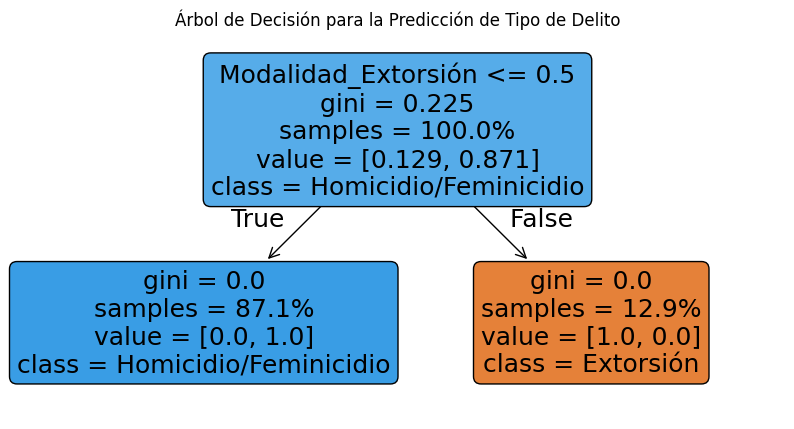

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Solo si el árbol no es demasiado grande, se puede visualizar.
# Para árboles grandes, esta visualización puede ser poco práctica.
# Puedes ajustar el max_depth para ver solo una parte del árbol.

plt.figure(figsize=(10,5))
plot_tree(cart_model,
          feature_names=X_encoded.columns.tolist(),
          class_names=le.classes_.tolist(),
          filled=True,
          rounded=True,
          proportion=True,
          max_depth=3) # Limitar la profundidad para una mejor visualización
plt.title("Árbol de Decisión para la Predicción de Tipo de Delito")
plt.show()

**Comentario Final:** respecto a este modelo tengo dos comentarios.

+ EL primero es que hice varias pruebas y el modelo siempre da una scores del 100%... ¿por qué? porque en el resto de columnas hay información que le hace tomar muy fácil la desición. Por ejemplo estaba una columna llamada `subtipo de delito` así que la borré, pero ahora se basa en otra que se llama `Modalidad_extorsion` y con eso decide, lo cual me da a mi mucha lógica del por qué el modelo es 100% certero.

+ Abajo de esta celda le dejo la lista de variables y pues si al final también quito modalidad sí cambian las metricas pero no se si esto le convenza. Por si las moscas vuelvo a corres todo del modelo pero sin la variable `Modalidad` y se lo dejo para que conserve el que le parezca mejor.

In [26]:
filtered_violencia.columns

Index(['Año', 'Clave_Ent', 'Entidad', 'Bien jurídico afectado',
       'Subtipo de delito', 'Modalidad', 'Sexo', 'Rango de edad',
       'target_delito', 'Suma_Meses'],
      dtype='object')

## Modelo CART eliminando 'Modalidad'

In [27]:
# Definir la variable objetivo (y) y las variables predictoras (X)
y = filtered_violencia['target_delito']
# Eliminar la variable objetivo y otras columnas que no son predictoras o son duplicadas/redundantes
X = filtered_violencia.drop(columns=['target_delito', 'Clave_Ent', 'Entidad', 'Bien jurídico afectado', 'Subtipo de delito', 'Modalidad'])

# Identificar columnas categóricas en X que necesitan One-Hot Encoding
categorical_cols = X.select_dtypes(include=['object']).columns

# Aplicar One-Hot Encoding a las variables categóricas en X
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Codificar la variable objetivo 'target_delito' si es categórica (Label Encoding)
# Aunque el DecisionTreeClassifier puede manejar directamente etiquetas de cadena, es una buena práctica.
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Dimensiones de X después de One-Hot Encoding: {X_encoded.shape}")
print(f"Clases codificadas de Y: {le.classes_}")

Dimensiones de X después de One-Hot Encoding: (13766, 7)
Clases codificadas de Y: ['Extorsión' 'Homicidio/Feminicidio']


In [28]:
# Dividir los datos en conjuntos de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Tamaño del conjunto de entrenamiento X: {X_train.shape}")
print(f"Tamaño del conjunto de prueba X: {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento y: {y_train.shape}")
print(f"Tamaño del conjunto de prueba y: {y_test.shape}")

# Inicializar y entrenar el modelo CART (DecisionTreeClassifier)
cart_model = DecisionTreeClassifier(random_state=42)
cart_model.fit(X_train, y_train)

print("Modelo CART entrenado exitosamente.")

Tamaño del conjunto de entrenamiento X: (11012, 7)
Tamaño del conjunto de prueba X: (2754, 7)
Tamaño del conjunto de entrenamiento y: (11012,)
Tamaño del conjunto de prueba y: (2754,)
Modelo CART entrenado exitosamente.


In [29]:
# Realizar predicciones en el conjunto de prueba
y_pred = cart_model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nPrecisión (Accuracy) del modelo CART: {accuracy:.2f}")
print("\nReporte de Clasificación del modelo CART:")
print(report)


Precisión (Accuracy) del modelo CART: 0.81

Reporte de Clasificación del modelo CART:
                       precision    recall  f1-score   support

            Extorsión       0.15      0.11      0.13       356
Homicidio/Feminicidio       0.87      0.91      0.89      2398

             accuracy                           0.81      2754
            macro avg       0.51      0.51      0.51      2754
         weighted avg       0.78      0.81      0.79      2754



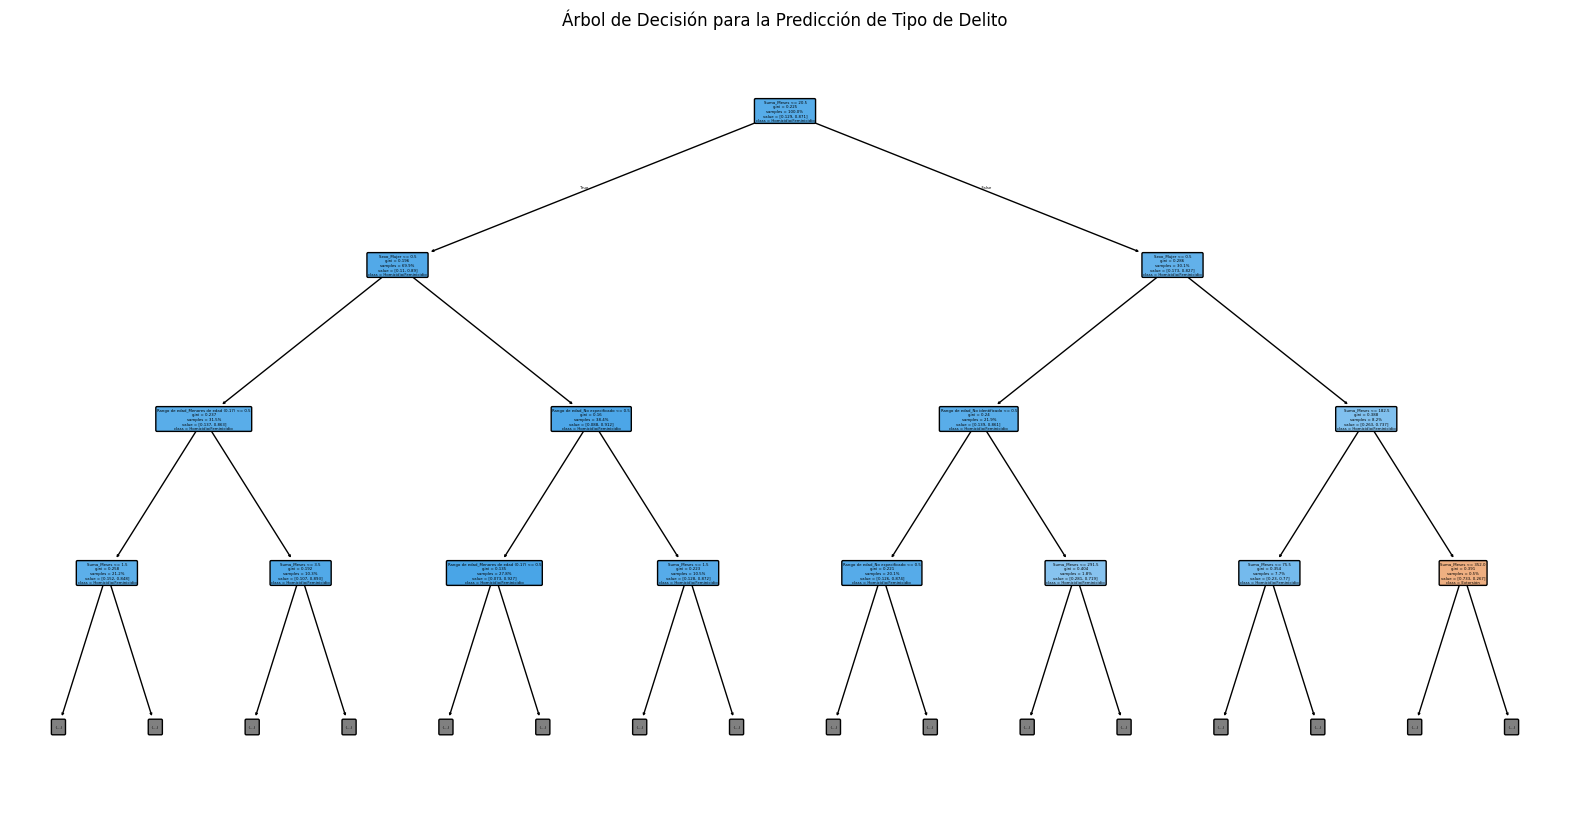

In [30]:
fig = plt.figure(figsize=(20,10))
plot_tree(cart_model,
          feature_names=X_encoded.columns.tolist(),
          class_names=le.classes_.tolist(),
          filled=True,
          rounded=True,
          proportion=True,
          max_depth=3) # Limitar la profundidad para una mejor visualización
plt.title("Árbol de Decisión para la Predicción de Tipo de Delito")
plt.show()

In [31]:
fig.savefig('tree_cart.pdf')